<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1803 | Val: 440 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[DenseNet-121] Epoch   1/100 | LR: 3.44e-04 | train loss 0.8506 acc 0.637 | val loss 0.8070 acc 0.668 *


[DenseNet-121] Epoch   2/100 | LR: 3.44e-04 | train loss 0.6346 acc 0.724 | val loss 0.5626 acc 0.768 *


[DenseNet-121] Epoch   3/100 | LR: 3.44e-04 | train loss 0.5195 acc 0.790 | val loss 0.5224 acc 0.770 *


[DenseNet-121] Epoch   4/100 | LR: 3.44e-04 | train loss 0.4560 acc 0.815 | val loss 0.6665 acc 0.757


...

[DenseNet-121] Epoch  13/100 | LR: 3.44e-05 | train loss 0.1590 acc 0.931 | val loss 0.3579 acc 0.861


[DenseNet-121] Epoch  14/100 | LR: 3.44e-05 | train loss 0.1207 acc 0.946 | val loss 0.3511 acc 0.861


[DenseNet-121] Epoch  15/100 | LR: 3.44e-05 | train loss 0.1179 acc 0.951 | val loss 0.3578 acc 0.857


[DenseNet-121] Epoch  16/100 | LR: 3.44e-05 | train loss 0.1076 acc 0.953 | val loss 0.3542 acc 0.864


[DenseNet-121] Epoch  17/100 | LR: 3.44e-05 | train loss 0.1030 acc 0.957 | val loss 0.3552 acc 0.859

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 17.

[DenseNet-121] Restored best checkpoint (val loss = 0.3468)


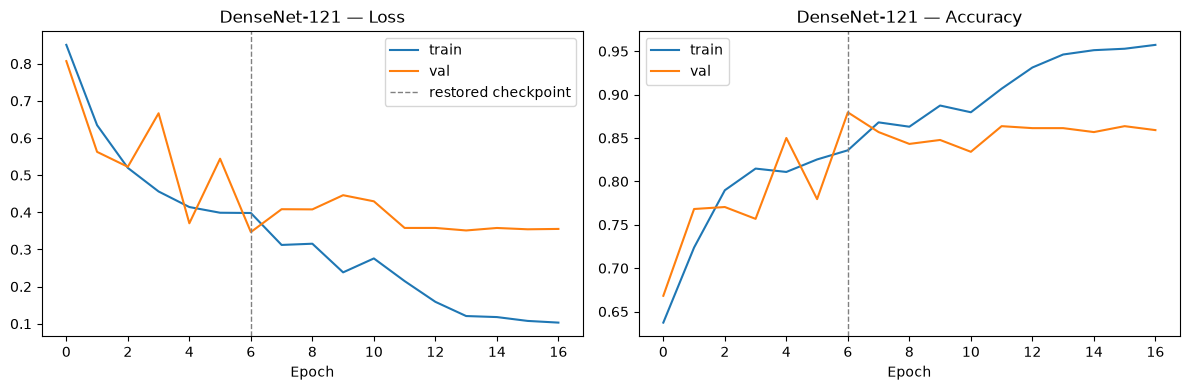

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.898


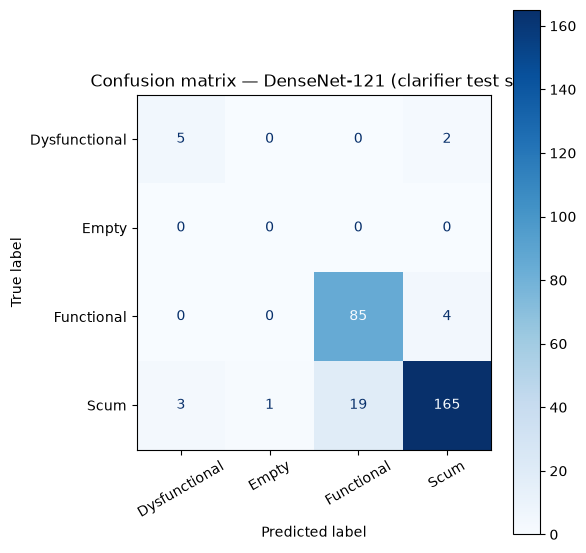

               precision    recall  f1-score   support

Dysfunctional      0.625     0.714     0.667         7
        Empty      0.000     0.000     0.000         0
   Functional      0.817     0.955     0.881        89
         Scum      0.965     0.878     0.919       188

     accuracy                          0.898       284
    macro avg      0.602     0.637     0.617       284
 weighted avg      0.910     0.898     0.901       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


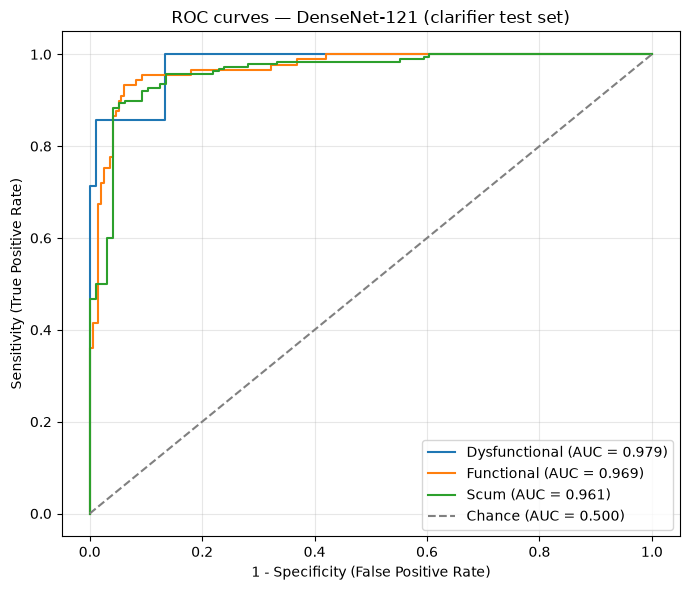

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.979
  Empty          : undefined (0 examples)
  Functional     : 0.969
  Scum           : 0.961

Mean AUC (over 3/4 classes with test examples): 0.970


(np.float64(0.897887323943662),
 {'Dysfunctional': 0.9793708096957194,
  'Empty': nan,
  'Functional': 0.9692883895131086,
  'Scum': 0.9608820921985816})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/clarifier_aug/results_clarifier_densenet121_Waterval.pkl


Saved model weights to ../models/clarifier_densenet121_cnn.pt
